In [5]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")

from src.experiments import run_validation, all_algos_on_all_datasets

In [6]:
results_small = run_validation(epochs=200, arh=[1, 8, 1], n_samples=50)
results_full = all_algos_on_all_datasets()

GD           | loss: 0.176716 | time: 0.034
Adam         | loss: 0.013173 | time: 0.024
LM           | loss: 0.010695 | time: 0.149
LMB          | loss: 0.009526 | time: 0.121
LBFGS        | loss: 0.010527 | time: 0.084

====== Dataset size: 50 samples ==========
--- Architecture: [1, 4, 1] --------------
GD           | loss: 0.147323 | time: 0.047
Adam         | loss: 0.010646 | time: 0.053
LM           | loss: 0.009893 | time: 0.236
LMB          | loss: 0.009025 | time: 0.164
LBFGS        | loss: 0.010562 | time: 0.033
-------------------------------------------
--- Architecture: [1, 8, 1] --------------
GD           | loss: 0.135693 | time: 0.051
Adam         | loss: 0.010475 | time: 0.056
LM           | loss: 0.007853 | time: 0.397
LMB          | loss: 0.007669 | time: 0.260
LBFGS        | loss: 0.010527 | time: 0.085
-------------------------------------------
--- Architecture: [1, 16, 1] --------------
GD           | loss: 0.179786 | time: 0.064
Adam         | loss: 0.010342 | ti

In [8]:
rows = []

for n_samples, arch_dict in results_full.items():
    for arch, opt_dict in arch_dict.items():
        for optimizer, metrics in opt_dict.items():
            rows.append({
                "dataset_size": int(n_samples),
                "architecture": arch,
                "width": int(arch.strip("[]").split(",")[1]),
                "optimizer": optimizer,
                "time": metrics["time"],
                "final_loss": metrics["final_loss"],
                "history": metrics["history"]
            })

df = pd.DataFrame(rows)
df.head()

,dataset_size,architecture,width,optimizer,time,final_loss,history
0,50,"[1, 4, 1]",4,GD,0.046808,0.147323,"[0.43386666632514875, 0.4321950293914245, 0.43..."
1,50,"[1, 4, 1]",4,Adam,0.052741,0.010646,"[0.4259838789479183, 0.4163657657190838, 0.406..."
2,50,"[1, 4, 1]",4,LM,0.236254,0.009893,"[0.4355183505102446, 0.4355183505102446, 0.127..."
3,50,"[1, 4, 1]",4,LMB,0.164057,0.009025,"[0.4355183505102446, 0.4355183505102446, 0.127..."
4,50,"[1, 4, 1]",4,LBFGS,0.032686,0.010562,"[0.19941461373327743, 0.19593821514883986, 0.1..."


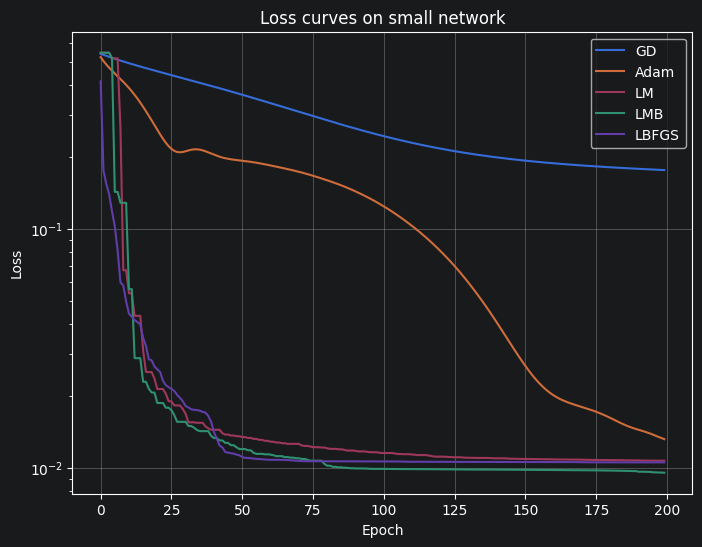

In [9]:
plt.figure(figsize=(8, 6))

for optimizer, metrics in results_small.items():
    plt.plot(metrics["history"], label=optimizer)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves on small network")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.savefig('../results/figures/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

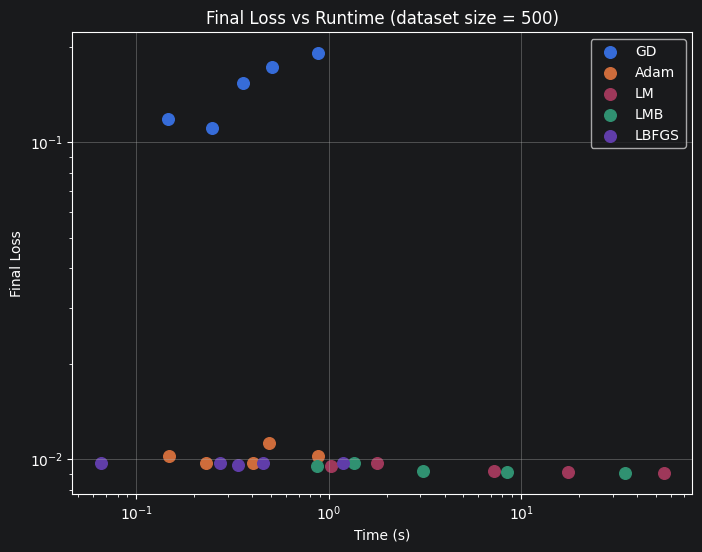

In [10]:
subset = df[df["dataset_size"] == 500]

plt.figure(figsize=(8, 6))

for optimizer in subset["optimizer"].unique():
    sub = subset[subset["optimizer"] == optimizer]
    plt.scatter(sub["time"], sub["final_loss"], label=optimizer, s=70)

plt.xlabel("Time (s)")
plt.ylabel("Final Loss")
plt.title("Final Loss vs Runtime (dataset size = 500)")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.savefig('../results/figures/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

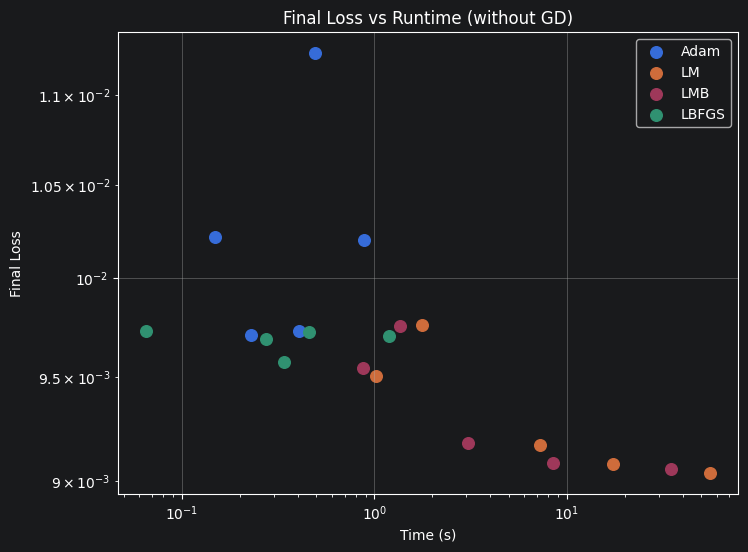

In [11]:
subset = df[(df["dataset_size"] == 500) & (df["optimizer"] != "GD")]

plt.figure(figsize=(8, 6))

for optimizer in subset["optimizer"].unique():
    sub = subset[subset["optimizer"] == optimizer]
    plt.scatter(sub["time"], sub["final_loss"], label=optimizer, s=70)

plt.xlabel("Time (s)")
plt.ylabel("Final Loss")
plt.title("Final Loss vs Runtime (without GD)")
plt.xscale("log")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.savefig('../results/figures/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

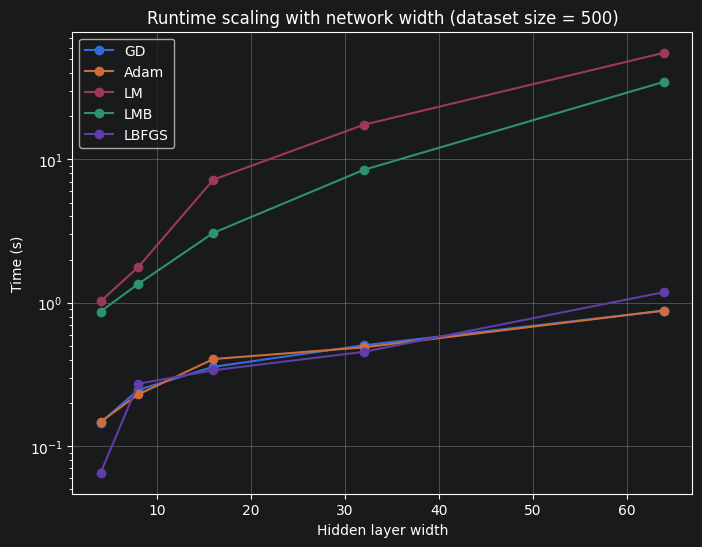

In [12]:
subset = df[df["dataset_size"] == 500]

plt.figure(figsize=(8, 6))

for optimizer in subset["optimizer"].unique():
    sub = subset[subset["optimizer"] == optimizer].sort_values("width")
    plt.plot(sub["width"], sub["time"], marker="o", label=optimizer)

plt.xlabel("Hidden layer width")
plt.ylabel("Time (s)")
plt.title("Runtime scaling with network width (dataset size = 500)")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.savefig('../results/figures/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

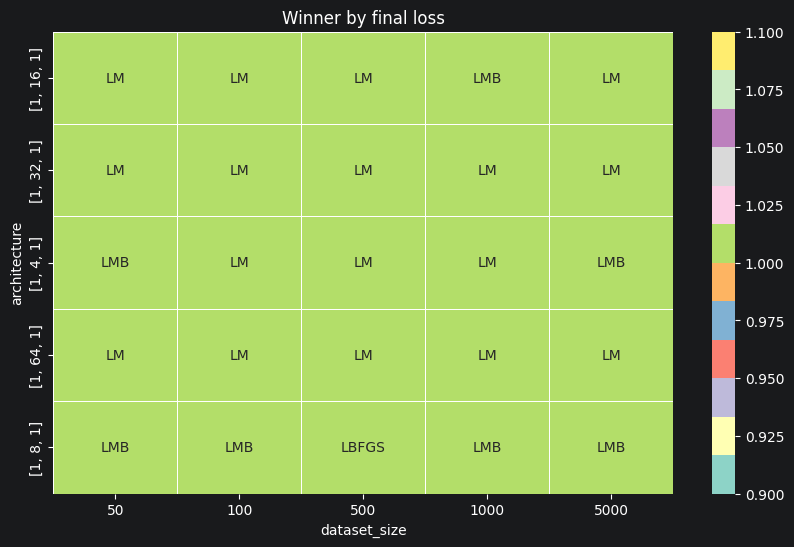

In [13]:
import seaborn as sns

winner_loss = df.groupby(['dataset_size', 'architecture']).apply(
    lambda g: g.loc[g['final_loss'].idxmin(), 'optimizer']
).reset_index(name='winner_loss')

winner_pivot = winner_loss.pivot(
    index='architecture',
    columns='dataset_size',
    values='winner_loss'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    winner_pivot.notna(),
    annot=winner_pivot.values,
    fmt='',
    cmap='Set3',
    linewidths=0.5
)
plt.title('Winner by final loss')
plt.savefig('../results/figures/heatmap_loss.png', dpi=150, bbox_inches='tight')
plt.show()


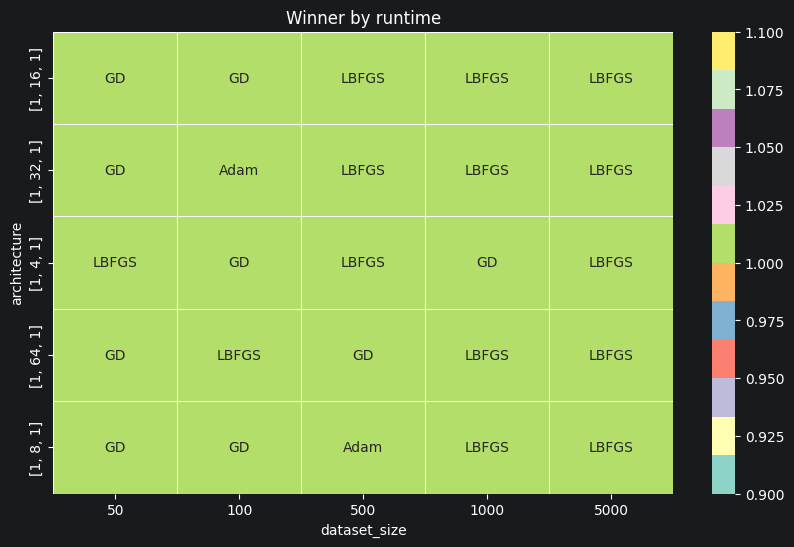

In [14]:
winner_time = df.groupby(['dataset_size', 'architecture']).apply(
    lambda g: g.loc[g['time'].idxmin(), 'optimizer']
).reset_index(name='winner_time')

winner_pivot_time = winner_time.pivot(
    index='architecture',
    columns='dataset_size',
    values='winner_time'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    winner_pivot_time.notna(),
    annot=winner_pivot_time.values,
    fmt='',
    cmap='Set3',
    linewidths=0.5
)
plt.title('Winner by runtime')
plt.savefig('../results/figures/heatmap_time.png', dpi=150, bbox_inches='tight')
plt.show()


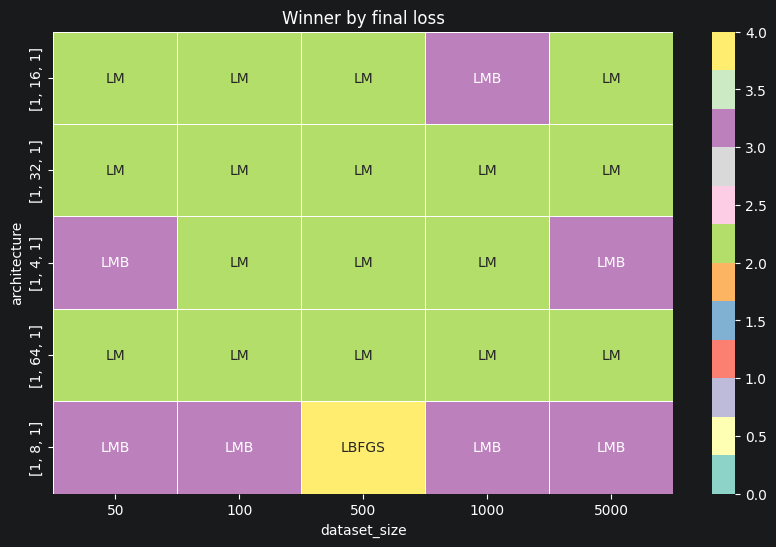

In [16]:
optimizer_names = ['GD', 'Adam', 'LM', 'LMB', 'LBFGS']
opt_to_num = {name: i for i, name in enumerate(optimizer_names)}

numeric_pivot = winner_pivot.map(lambda x: opt_to_num.get(x, -1))

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    numeric_pivot,
    annot=winner_pivot.values,
    fmt='',
    cmap='Set3',
    linewidths=0.5,
    vmin=0,
    vmax=len(optimizer_names)-1
)
plt.title('Winner by final loss')
plt.savefig('../results/figures/heatmap_loss.png', dpi=150, bbox_inches='tight')
plt.show()

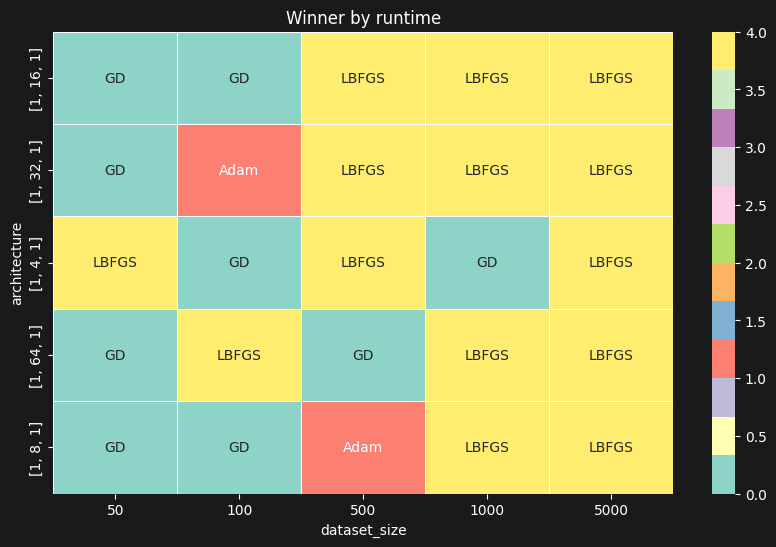

In [17]:
numeric_pivot_time = winner_pivot_time.map(lambda x: opt_to_num.get(x, -1))

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    numeric_pivot_time,
    annot=winner_pivot_time.values,
    fmt='',
    cmap='Set3',
    linewidths=0.5,
    vmin=0,
    vmax=len(optimizer_names)-1
)
plt.title('Winner by runtime')
plt.savefig('../results/figures/heatmap_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
def epochs_to_threshold(history, threshold=0.01):
    for i, loss in enumerate(history):
        if loss < threshold:
            return i
    return None

thresholds = [0.1, 0.05, 0.01, 0.005]

rows_conv = []
for name, metrics in results_small.items():
    for threshold in thresholds:
        epoch = epochs_to_threshold(metrics['history'], threshold)
        rows_conv.append({
            'optimizer': name,
            'threshold': threshold,
            'epochs': epoch
        })

df_conv = pd.DataFrame(rows_conv)
print(df_conv)


   optimizer  threshold  epochs
0         GD      0.100     NaN
1         GD      0.050     NaN
2         GD      0.010     NaN
3         GD      0.005     NaN
4       Adam      0.100   112.0
5       Adam      0.050   135.0
6       Adam      0.010     NaN
7       Adam      0.005     NaN
8         LM      0.100     8.0
9         LM      0.050    12.0
10        LM      0.010     NaN
11        LM      0.005     NaN
12       LMB      0.100    10.0
13       LMB      0.050    12.0
14       LMB      0.010    86.0
15       LMB      0.005     NaN
16     LBFGS      0.100     6.0
17     LBFGS      0.050     9.0
18     LBFGS      0.010     NaN
19     LBFGS      0.005     NaN


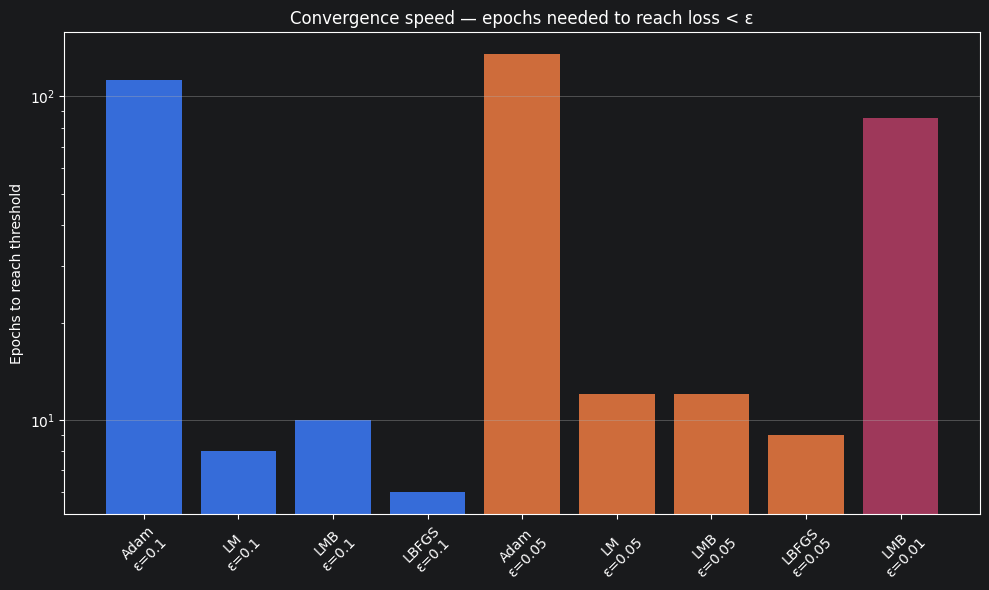

In [19]:
plt.figure(figsize=(10, 6))

for threshold in thresholds:
    subset = df_conv[df_conv['threshold'] == threshold]
    subset = subset.dropna()
    plt.bar(
        [f"{row['optimizer']}\nε={row['threshold']}" for _, row in subset.iterrows()],
        subset['epochs'],
        label=f"ε={threshold}"
    )

plt.ylabel("Epochs to reach threshold")
plt.title("Convergence speed — epochs needed to reach loss < ε")
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig('../results/figures/convergence_speed.png', dpi=150, bbox_inches='tight')
plt.show()


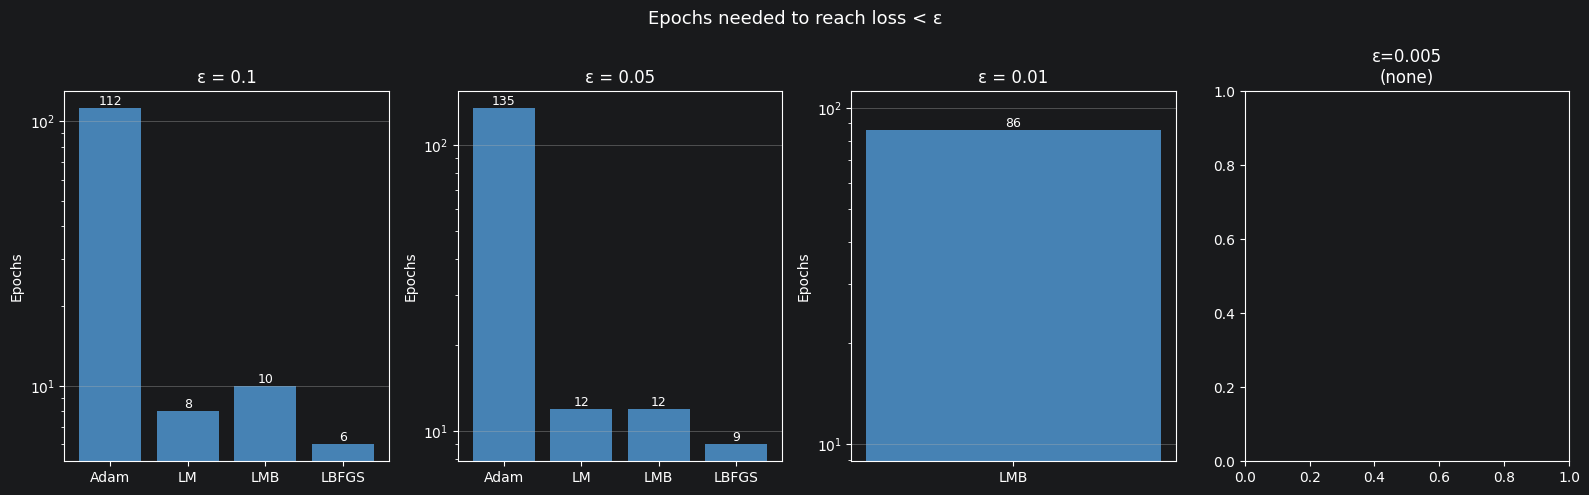

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, len(thresholds), figsize=(16, 5))

for ax, threshold in zip(axes, thresholds):
    subset = df_conv[df_conv['threshold'] == threshold].dropna()

    if subset.empty:
        ax.set_title(f"ε={threshold}\n(none)")
        continue

    bars = ax.bar(subset['optimizer'], subset['epochs'], color='steelblue')
    ax.set_title(f"ε = {threshold}")
    ax.set_ylabel("Epochs")
    ax.set_yscale('log')
    ax.grid(True, axis='y')

    for bar, val in zip(bars, subset['epochs']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                str(int(val)), ha='center', va='bottom', fontsize=9)

plt.suptitle("Epochs needed to reach loss < ε", fontsize=13)
plt.tight_layout()
plt.savefig('../results/figures/convergence_speed.png', dpi=150, bbox_inches='tight')
plt.show()
